Training shape: (300, 2)
Model trained successfully
Predictions:
[ 1  1  1 -1 -1 -1]
Decision scores:
[ 0.00648727  0.02460271  0.00645674 -1.9352868  -1.9352868  -1.9352868 ]


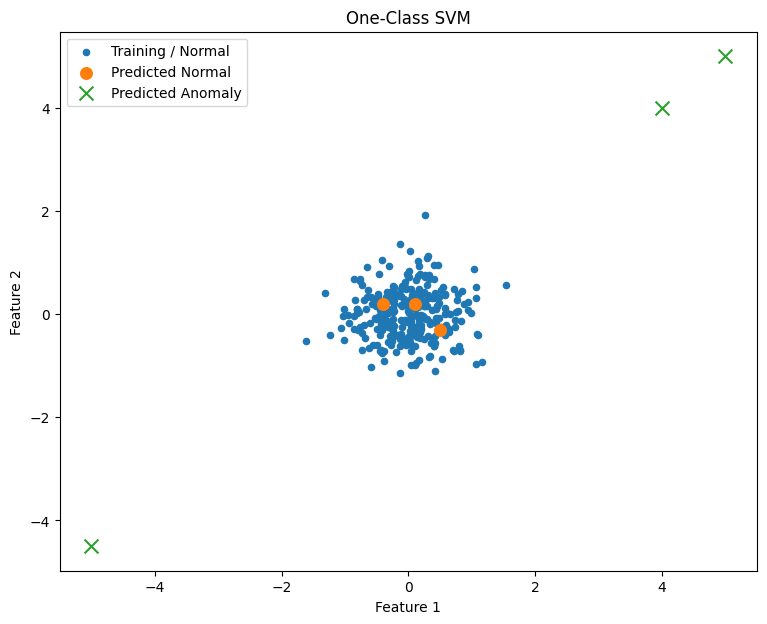

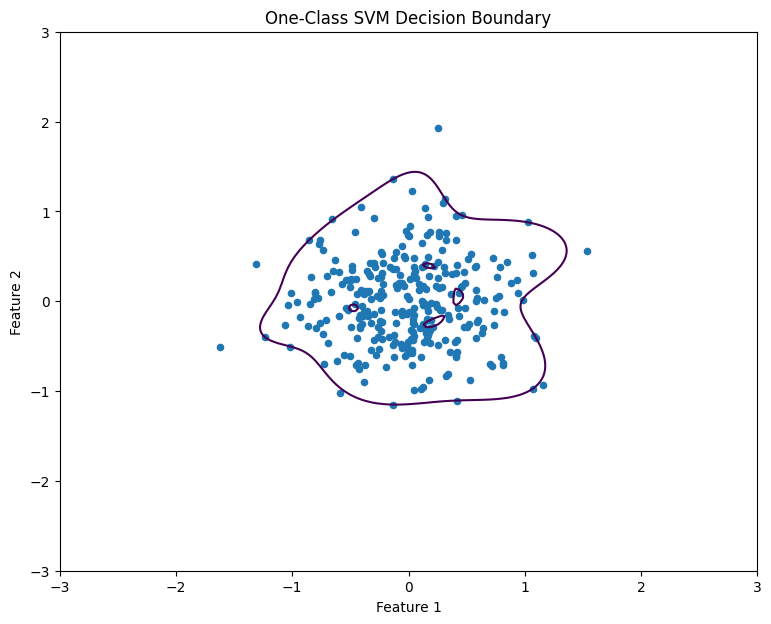

Scaled predictions:
[ 1  1  1 -1 -1 -1]


In [1]:
# ============================================================
# ONE-CLASS SVM — Anomaly Detection
# ============================================================
#
# LEVEL: 🟡 MEDIUM
#
# Goal:
#   Understand how One-Class SVM detects unusual observations
#   and learn the sklearn implementation.
#
# We will NOT implement the full SVM optimization from scratch.
#
# Topics:
#   1. Why One-Class SVM?
#   2. Intuition
#   3. Internal working
#   4. Important math
#   5. Kernel idea
#   6. Important parameters
#   7. sklearn implementation
#   8. New unseen data
#   9. Scaling
#  10. Compare with Isolation Forest / LOF
#  11. Interview questions
#  12. Working tree
#
# ============================================================


# ============================================================
# 1. WHY ONE-CLASS SVM?
# ============================================================

# Normal supervised SVM:
#
#     Input X + labels y
#              |
#              v
#          Find boundary
#              |
#              v
#       Class 1 / Class 2
#
#
# But anomaly detection often looks like:
#
#     We have mostly NORMAL data
#
#     ● ● ● ● ●
#    ● ● ● ● ● ●
#     ● ● ● ● ●
#
# and we want to identify:
#
#                         X
#
# as an anomaly.
#
#
# One-Class SVM learns a boundary around the normal data.
#
#
# Main idea:
#
#     Learn what NORMAL data looks like.
#
#     New point inside boundary
#         → normal
#
#     New point outside boundary
#         → anomaly
#
#
# ============================================================
# 2. INTUITION
# ============================================================

# Imagine normal observations form this region:
#
#
#             ● ● ●
#          ● ● ● ● ●
#         ● ● ● ● ● ●
#          ● ● ● ● ●
#             ● ● ●
#
#
# One-Class SVM tries to learn a boundary around this region.
#
#
#             ___________
#          .-'           '-.
#        .'    ● ● ● ●      '.
#       /   ● ● ● ● ● ●       \
#      |    ● ● ● ● ● ●        |
#       \     ● ● ● ●         /
#        '.                 .'
#          '-.___________.-'
#
#
# A new point:
#
#             X
#
# outside the learned region:
#
#     → anomaly
#
#
# ============================================================
# 3. WHY "ONE-CLASS"?
# ============================================================

# Normal SVM:
#
#     Class +1
#          vs
#     Class -1
#
#
# One-Class SVM:
#
#     Mainly learns:
#
#          NORMAL CLASS
#
#
# There is no requirement for a separate anomaly class.
#
#
# Therefore:
#
#     One-Class SVM
#         ↓
#     novelty / outlier detection
#
#
# ============================================================
# 4. INTERNAL WORKING — HIGH LEVEL
# ============================================================

# One-Class SVM roughly does:
#
#
#     Normal training data
#             |
#             v
#     Map data into feature space
#             |
#             v
#     Find a boundary separating
#     normal data from the origin
#             |
#             v
#     Learn decision function
#             |
#             v
#     New observation
#             |
#        ----------------
#        |              |
#        v              v
#     inside          outside
#        |              |
#        v              v
#      NORMAL        ANOMALY
#
#
# The important trick is:
#
#     Instead of explicitly modeling "all anomalies",
#     learn the region containing normal observations.
#
#
# ============================================================
# 5. THE ORIGIN IDEA
# ============================================================

# This is an important conceptual detail.
#
# One-Class SVM transforms the problem into something
# similar to:
#
#     Separate normal observations from the origin.
#
#
# In feature space:
#
#     normal data
#
#       ● ● ● ●
#      ● ● ● ● ●
#       ● ● ● ●
#
#
# versus:
#
#               O
#
#             origin
#
#
# The algorithm finds a decision boundary such that
# normal observations are separated from the origin
# as well as possible.
#
#
# You don't need to reproduce the optimization in an interview.
#
# Remember:
#
#     "One-Class SVM learns a boundary around normal data
#      by separating the mapped normal observations from
#      the origin."
#
#
# ============================================================
# 6. IMPORTANT MATHEMATICAL IDEA
# ============================================================

# The One-Class SVM optimization can be expressed as:
#
#
# minimize:
#
#     1/2 ||w||²
#     + (1 / (νn)) Σ ξ_i
#     - ρ
#
#
# subject to:
#
#     w · φ(x_i) >= ρ - ξ_i
#
#     ξ_i >= 0
#
#
# where:
#
#     w
#         = learned separating hyperplane
#
#     φ(x)
#         = feature mapping
#
#     ξ_i
#         = allowed violations/slack
#
#     ρ
#         = offset / threshold
#
#     ν
#         = important hyperparameter
#
#
# The key practical parameter is:
#
#     ν (nu)
#
#
# ============================================================
# 7. WHAT DOES ν (nu) CONTROL?
# ============================================================

# ν is one of the MOST IMPORTANT One-Class SVM parameters.
#
#
# Conceptually, ν controls the allowed fraction of
# training observations treated as outliers.
#
#
# ν is between:
#
#     0 < ν <= 1
#
#
# Example:
#
#     nu = 0.05
#
# roughly allows around 5% of training observations
# to be treated as outliers.
#
#
# ν also controls the complexity / number of support vectors.
#
#
# Smaller ν:
#
#     fewer points allowed outside
#     tighter assumptions about normal data
#
#
# Larger ν:
#
#     more points can be treated as outliers
#     more flexible boundary
#
#
# IMPORTANT:
#
# Do not interpret ν as simply:
#
#     "exactly 5% anomalies."
#
# It acts as a bound/control parameter in the optimization.
#
#
# ============================================================
# 8. KERNELS
# ============================================================

# One-Class SVM can use kernels.
#
# Why?
#
# Because normal data may have a nonlinear shape.
#
#
# Example:
#
#     Normal data forms a circle:
#
#
#             ● ● ●
#          ●         ●
#         ●           ●
#          ●         ●
#             ● ● ●
#
#
# A linear boundary may not work well.
#
#
# A nonlinear kernel can transform the data into
# a feature space where separation is easier.
#
#
# ============================================================
# 9. RBF KERNEL
# ============================================================

# The most commonly used nonlinear kernel is:
#
#     RBF
#
#
# Formula:
#
#
# K(x, x')
#
#     = exp(
#         -γ ||x - x'||²
#       )
#
#
# where:
#
#     γ = gamma
#
#
# Interpretation:
#
#     Similar points
#         → kernel value close to 1
#
#     Very different points
#         → kernel value close to 0
#
#
# ============================================================
# 10. GAMMA
# ============================================================

# gamma controls how local the RBF kernel is.
#
#
# HIGH gamma:
#
#     each point has a more local influence
#
#     boundary can become very flexible
#
#     higher risk of overfitting
#
#
# LOW gamma:
#
#     broader influence
#
#     smoother boundary
#
#     may underfit
#
#
# Mental model:
#
#     gamma ↑
#         ↓
#     more local
#         ↓
#     more complex boundary
#
#
#     gamma ↓
#         ↓
#     broader influence
#         ↓
#     smoother boundary
#
#
# ============================================================
# 11. KERNEL OPTIONS
# ============================================================

# Common choices:
#
#     kernel="rbf"
#     kernel="linear"
#     kernel="poly"
#     kernel="sigmoid"
#
#
# RBF:
#
#     nonlinear
#     common default
#
#
# Linear:
#
#     simpler
#     useful when data is approximately linearly separable
#
#
# ============================================================
# 12. IMPORTANT PARAMETERS
# ============================================================

# nu:
#
#     Controls the allowed fraction of training outliers
#     and support-vector behavior.
#
#
# kernel:
#
#     "rbf"
#     "linear"
#     "poly"
#     "sigmoid"
#
#
# gamma:
#
#     Controls RBF / polynomial / sigmoid kernel influence.
#
#
# degree:
#
#     Degree of polynomial kernel.
#
#
# coef0:
#
#     Independent term in polynomial/sigmoid kernels.
#
#
# tol:
#
#     Optimization stopping tolerance.
#
#
# shrinking:
#
#     Whether shrinking heuristic is used.
#
#
# cache_size:
#
#     Kernel cache size in MB.
#
#
# max_iter:
#
#     Maximum optimization iterations.
#
#
# ============================================================
# 13. PARAMETERS YOU REALLY NEED TO REMEMBER
# ============================================================

# For interviews and practical ML:
#
#
#     nu
#     kernel
#     gamma
#
#
# These are the most important.
#
#
# Typical starting point:
#
#     kernel="rbf"
#     nu=0.05
#     gamma="scale"
#
#
# ============================================================
# 14. IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import OneClassSVM


# ============================================================
# 15. CREATE NORMAL DATA
# ============================================================

# Training data mainly contains normal observations.
#
rng = np.random.RandomState(42)

X_normal = 0.5 * rng.randn(300, 2)

print("Training shape:", X_normal.shape)


# ============================================================
# 16. TRAIN ONE-CLASS SVM
# ============================================================

model = OneClassSVM(
    kernel="rbf",
    nu=0.05,
    gamma="scale"
)

model.fit(X_normal)

print("Model trained successfully")


# ============================================================
# 17. CREATE NEW DATA
# ============================================================

# Some points are close to the normal distribution.
#
# Some are far away.
#

X_test = np.array([
    [0.1, 0.2],
    [0.5, -0.3],
    [-0.4, 0.2],
    [4.0, 4.0],
    [5.0, 5.0],
    [-5.0, -4.5]
])


# ============================================================
# 18. PREDICT
# ============================================================

predictions = model.predict(X_test)

# sklearn convention:
#
#     +1 → normal
#     -1 → anomaly
#

print("Predictions:")
print(predictions)


# ============================================================
# 19. DECISION FUNCTION
# ============================================================

# decision_function gives a score relative to the
# learned boundary.
#
#
# Positive:
#
#     more likely normal
#
#
# Negative:
#
#     more likely anomaly
#

scores = model.decision_function(X_test)

print("Decision scores:")
print(scores)


# ============================================================
# 20. VISUALIZE
# ============================================================

plt.figure(figsize=(9, 7))

plt.scatter(
    X_normal[:, 0],
    X_normal[:, 1],
    label="Training / Normal",
    s=20
)

plt.scatter(
    X_test[predictions == 1, 0],
    X_test[predictions == 1, 1],
    label="Predicted Normal",
    s=70
)

plt.scatter(
    X_test[predictions == -1, 0],
    X_test[predictions == -1, 1],
    label="Predicted Anomaly",
    s=100,
    marker="x"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("One-Class SVM")
plt.legend()

plt.show()


# ============================================================
# 21. VISUALIZE DECISION REGION
# ============================================================

# We can visualize the learned decision boundary
# for a 2D dataset.
#

x_min, x_max = -3, 3
y_min, y_max = -3, 3

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[
    xx.ravel(),
    yy.ravel()
]

Z = model.decision_function(grid)

Z = Z.reshape(xx.shape)


plt.figure(figsize=(9, 7))

plt.contour(
    xx,
    yy,
    Z,
    levels=[0]
)

plt.scatter(
    X_normal[:, 0],
    X_normal[:, 1],
    s=20
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("One-Class SVM Decision Boundary")

plt.show()


# ============================================================
# 22. EFFECT OF nu
# ============================================================

# nu controls how much training data can be considered
# anomalous / outside the learned region.
#
#
# For learning purposes, you can try:
#
#     nu = 0.01
#     nu = 0.05
#     nu = 0.10
#
#
# BUT:
#
# Do not repeatedly run expensive experiments on huge
# datasets.
#
#
# Example configuration:
#
# model = OneClassSVM(
#     kernel="rbf",
#     nu=0.05,
#     gamma="scale"
# )
#
#
# ============================================================
# 23. EFFECT OF gamma
# ============================================================

# gamma controls how local the RBF kernel is.
#
#
# Low gamma:
#
#     smoother boundary
#
#
# High gamma:
#
#     more flexible/local boundary
#
#
# Example:
#
# model = OneClassSVM(
#     kernel="rbf",
#     nu=0.05,
#     gamma=0.1
# )
#
#
# or:
#
# model = OneClassSVM(
#     kernel="rbf",
#     nu=0.05,
#     gamma=1.0
# )
#
#
# Don't tune blindly.
#
# Use validation data / domain knowledge where possible.
#
#
# ============================================================
# 24. WHY SCALING IS IMPORTANT
# ============================================================

# One-Class SVM is very sensitive to feature scale,
# especially with the RBF kernel.
#
#
# Example:
#
#     age:
#         20 → 60
#
#     salary:
#         20,000 → 2,000,000
#
#
# Salary can dominate distances/kernel calculations.
#
#
# Therefore:
#
#     StandardScaler
#
# is usually a good preprocessing step for numerical features.
#
#
# ============================================================
# 25. STANDARDIZED VERSION
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_normal_scaled = scaler.fit_transform(X_normal)


scaled_model = OneClassSVM(
    kernel="rbf",
    nu=0.05,
    gamma="scale"
)

scaled_model.fit(X_normal_scaled)


# Transform new data using the SAME scaler.
#
X_test_scaled = scaler.transform(X_test)


scaled_predictions = scaled_model.predict(
    X_test_scaled
)

print("Scaled predictions:")
print(scaled_predictions)


# ============================================================
# 26. IMPORTANT TRAINING PRINCIPLE
# ============================================================

# Ideally, the training data should represent NORMAL behavior.
#
#
# Example:
#
# Fraud detection:
#
#     Training data → mostly/known normal transactions
#
#
# Machine monitoring:
#
#     Training data → normal machine operation
#
#
# Network monitoring:
#
#     Training data → normal traffic
#
#
# Then:
#
#     New observation
#            ↓
#      One-Class SVM
#            ↓
#     normal / anomaly
#
#
# ============================================================
# 27. ONE-CLASS SVM vs NORMAL SVM
# ============================================================

# NORMAL SVM:
#
#     Supervised.
#
#     Training:
#
#         X + labels
#
#     Example:
#
#         Class A
#         Class B
#
#
# ONE-CLASS SVM:
#
#     Usually trained using normal observations.
#
#     Goal:
#
#         Learn the region containing normal data.
#
#
# Normal SVM:
#
#     "Separate known classes."
#
#
# One-Class SVM:
#
#     "Learn the boundary of normal behavior."
#
#
# ============================================================
# 28. ONE-CLASS SVM vs ISOLATION FOREST
# ============================================================

# Isolation Forest:
#
#     Tree-based.
#
#     Randomly partitions observations.
#
#     Anomaly signal:
#
#         Short isolation path.
#
#
# One-Class SVM:
#
#     Boundary/kernel-based.
#
#     Learns a region around normal observations.
#
#     Anomaly signal:
#
#         Outside learned boundary.
#
#
# Practical difference:
#
#     Isolation Forest
#         → usually scales more comfortably to large datasets.
#
#
#     One-Class SVM
#         → can become expensive on large datasets,
#           especially with nonlinear kernels.
#
#
# ============================================================
# 29. ONE-CLASS SVM vs LOF
# ============================================================

# LOF:
#
#     Local density.
#
#     "Am I less dense than my neighbors?"
#
#
# One-Class SVM:
#
#     Learned boundary.
#
#     "Am I outside the region representing normal data?"
#
#
# LOF:
#
#     Neighborhood-based.
#
#
# One-Class SVM:
#
#     Kernel/boundary-based.
#
#
# ============================================================
# 30. ONE-CLASS SVM vs DBSCAN
# ============================================================

# DBSCAN:
#
#     Density-based clustering.
#
#     Finds clusters and noise.
#
#
# One-Class SVM:
#
#     Learns a boundary around normal observations.
#
#
# DBSCAN:
#
#     eps + min_samples
#
#
# One-Class SVM:
#
#     nu + kernel + gamma
#
#
# ============================================================
# 31. ADVANTAGES
# ============================================================

# 1. Can model nonlinear normal-data boundaries.
#
# 2. Kernel trick allows complex boundaries.
#
# 3. Works when anomaly labels are unavailable.
#
# 4. Useful when normal behavior forms a meaningful region.
#
# 5. Can score new unseen observations.
#
#
# ============================================================
# 32. LIMITATIONS
# ============================================================

# 1. Sensitive to feature scaling.
#
# 2. Sensitive to hyperparameters.
#
# 3. RBF kernel can be computationally expensive.
#
# 4. Not ideal for extremely large datasets.
#
# 5. Choosing nu can be difficult.
#
# 6. Choosing gamma can strongly affect the boundary.
#
# 7. Poor feature representation can lead to poor anomaly
#    detection.
#
#
# ============================================================
# 33. WHEN TO USE ONE-CLASS SVM
# ============================================================

# Useful when:
#
#     - You mainly have normal training data.
#     - Dataset size is manageable.
#     - Nonlinear normal boundaries are important.
#     - You need predictions on new observations.
#     - You can properly scale the features.
#
#
# Example:
#
#     Industrial machine behavior
#     Network traffic
#     Sensor monitoring
#     User behavior
#     Quality control
#
#
# ============================================================
# 34. WHEN NOT TO USE IT
# ============================================================

# Avoid it as the first choice when:
#
#     - Dataset is extremely large.
#     - Feature count is extremely high.
#     - You need very fast training.
#     - Hyperparameter tuning is difficult.
#
#
# In those situations:
#
#     Isolation Forest
#
# can often be a better starting point.
#
#
# ============================================================
# 35. INTERVIEW QUESTIONS
# ============================================================

# Q1. What is One-Class SVM?
#
# Answer:
#
# One-Class SVM is an unsupervised/semi-supervised anomaly
# detection technique that learns a boundary around normal
# observations and identifies observations outside that
# boundary as anomalies.
#
#
# Q2. Why is it called One-Class SVM?
#
# Answer:
#
# Because it primarily learns from one class of observations,
# usually the normal class, instead of requiring labeled
# normal and anomaly examples.
#
#
# Q3. What is nu?
#
# Answer:
#
# nu controls the allowed fraction of training errors/outliers
# and also provides a bound related to the fraction of support
# vectors.
#
#
# Q4. What does gamma do?
#
# Answer:
#
# For the RBF kernel, gamma controls how local the influence
# of each training point is. Higher gamma produces a more
# flexible/local boundary, while lower gamma produces a
# smoother boundary.
#
#
# Q5. Why use RBF?
#
# Answer:
#
# RBF allows One-Class SVM to learn nonlinear boundaries
# around normal observations.
#
#
# Q6. Why scale the data?
#
# Answer:
#
# Kernel calculations are sensitive to feature magnitude,
# so unscaled features can distort the learned boundary.
#
#
# Q7. One-Class SVM vs Isolation Forest?
#
# Answer:
#
# One-Class SVM learns a boundary around normal data using
# SVM/kernel methods, while Isolation Forest identifies
# anomalies using random tree isolation and path length.
#
#
# Q8. What does predict() return?
#
# Answer:
#
#     +1 → normal
#     -1 → anomaly
#
#
# ============================================================
# 36. 30-SECOND INTERVIEW ANSWER
# ============================================================

# "One-Class SVM is an anomaly detection algorithm that learns
# a boundary around normal observations instead of requiring
# examples of the anomaly class. It maps the data into a feature
# space, often using an RBF kernel, and learns a decision
# boundary separating normal observations from the origin.
# New points outside the learned boundary are classified as
# anomalies. The key parameters are nu, kernel and gamma."
#
#
# ============================================================
# 37. WORKING TREE
# ============================================================

#                    NORMAL TRAINING DATA
#                             |
#                             v
#                       Scale features
#                             |
#                             v
#                       Kernel mapping
#                             |
#                             v
#                Map data into feature space
#                             |
#                             v
#              Separate normal data from origin
#                             |
#                             v
#                 Learn decision boundary
#                             |
#                             v
#                      NEW OBSERVATION
#                             |
#                             v
#                   Evaluate decision function
#                             |
#                   ---------------------
#                   |                   |
#                   v                   v
#               Inside              Outside
#                   |                   |
#                   v                   v
#                NORMAL              ANOMALY
#
#
# ============================================================
# 38. FINAL MENTAL MODEL
# ============================================================

# Isolation Forest:
#
#     "How quickly can I isolate this point?"
#
#
# LOF:
#
#     "Is this point less dense than its neighbors?"
#
#
# One-Class SVM:
#
#     "Is this point outside the learned boundary
#      of normal behavior?"
#
#
# DBSCAN:
#
#     "Is this point part of a sufficiently dense region?"
#
#
# ============================================================
# 39. ANOMALY DETECTION COMPLETE
# ============================================================
#
#     Isolation Forest
#          ↓
#     Random isolation trees
#          ↓
#     Short path = anomaly
#
#
#     LOF
#          ↓
#     Local neighborhood density
#          ↓
#     Low relative density = anomaly
#
#
#     One-Class SVM
#          ↓
#     Learn normal-data boundary
#          ↓
#     Outside boundary = anomaly
#
#
# ============================================================
# END
# ============================================================